In [1]:
import numpy as np
import h5py
import re
import matplotlib.pyplot as plt
from pathlib import Path

Path("fig").mkdir(exist_ok=True)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

In [2]:
# -- Variable-step data (new top-level h5 layout; compatible with old segmented files) --
file_vs = "data/ns_SDIRK2_mr_SAV_bursting_40_4_4_vs.h5"

traj_keys = ["tn", "Energy", "Enstrophy", "Palinstrophy", "CPU_time"]
optional_traj_keys = ["Energy_rate", "Enstrophy_rate"]

def load_bursting_h5(path):
    """Load either the new top-level layout or the old segmented group layout."""
    with h5py.File(path, "r") as f:
        if "tn" in f and "Omega" in f:
            out = {
                "layout": "top-level",
                "tn": f["tn"][:],
                "tn_s": f["tn_s"][:],
                "tau": f["tau"][:] if "tau" in f else np.asarray(f.attrs.get("tau")),
                "Energy": f["Energy"][:],
                "Enstrophy": f["Enstrophy"][:],
                "Palinstrophy": f["Palinstrophy"][:],
                "CPU_time": f["CPU_time"][:],
                "Omega_shape": f["Omega"].shape,
            }
            for key in optional_traj_keys:
                if key in f:
                    out[key] = f[key][:]
            return out

        intervals = []
        for name in f.keys():
            m = re.match(r"t_([0-9.]+)_([0-9.]+)", name)
            if m:
                intervals.append((float(m.group(1)), float(m.group(2)), name))
        intervals.sort(key=lambda x: x[0])
        if not intervals:
            raise ValueError(f"No top-level datasets or t_* groups found in {path}")

        arrays = {k: [] for k in traj_keys}
        optional_arrays = {k: [] for k in optional_traj_keys}
        arrays["tn_s"] = []
        omega_count = 0
        omega_spatial_shape = None
        tau_list = []
        for i, (_, _, name) in enumerate(intervals):
            grp = f[name]
            skip = 1 if i > 0 else 0
            for k in traj_keys:
                arrays[k].append(grp[k][skip:])
            for k in optional_traj_keys:
                if k in grp:
                    optional_arrays[k].append(grp[k][skip:])
            arrays["tn_s"].append(grp["tn_s"][skip:])
            omega_count += grp["Omega"].shape[0] - skip
            omega_spatial_shape = grp["Omega"].shape[1:]
            if "tau" in grp:
                tau_list.append(grp["tau"][skip:])

        out = {
            "layout": "segmented",
            "segments": [name for _, _, name in intervals],
            **{k: np.concatenate(v) for k, v in arrays.items()},
            "Omega_shape": (omega_count, *omega_spatial_shape),
        }
        for k, chunks in optional_arrays.items():
            if chunks:
                out[k] = np.concatenate(chunks)
        if tau_list:
            out["tau"] = np.concatenate(tau_list)
        return out

def trapezoidal_point_weights(time):
    """Return node weights for time integrals on a nonuniform grid."""
    time = np.asarray(time, dtype=np.float64)
    if len(time) < 2:
        raise ValueError("At least two time points are required.")
    dt = np.diff(time)
    if np.any(dt <= 0):
        raise ValueError("Time points must be strictly increasing.")
    weights = np.empty_like(time)
    weights[0] = 0.5 * dt[0]
    weights[-1] = 0.5 * dt[-1]
    weights[1:-1] = 0.5 * (dt[:-1] + dt[1:])
    return weights

data_vs = load_bursting_h5(file_vs)
tn_vs        = data_vs["tn"]
tn_s_vs      = data_vs["tn_s"]
tau_vs       = data_vs["tau"]
Energy_vs    = data_vs["Energy"]
Energy_rate_vs = data_vs.get("Energy_rate")
Enstrophy_vs = data_vs["Enstrophy"]
Enstrophy_rate_vs = data_vs.get("Enstrophy_rate")
Palin_vs     = data_vs["Palinstrophy"]
CPU_vs       = data_vs["CPU_time"]

print(f"VS  | layout: {data_vs['layout']}")
print(f"VS  | tn:     {tn_vs.shape}, tn_s: {tn_s_vs.shape}, Omega: {data_vs['Omega_shape']}")
print(f"VS  | t range: [{tn_s_vs[0]:.3f}, {tn_s_vs[-1]:.3f}]")
print(f"VS  | tau range: [{tau_vs.min():.2e}, {tau_vs.max():.2e}]")
print(f"VS  | stored rates: Energy_rate={Energy_rate_vs is not None}, Enstrophy_rate={Enstrophy_rate_vs is not None}")


VS  | layout: top-level
VS  | tn:     (1179985,), tn_s: (1001,), Omega: (1001, 128, 128)
VS  | t range: [0.000, 10000.000]
VS  | tau range: [5.00e-04, 1.00e-02]
VS  | stored rates: Energy_rate=True, Enstrophy_rate=True


In [3]:
# -- Fixed-step data: load two fixed time-step runs without overwriting them --
fixed_step_files = {
    "tau=1e-3": {
        "path": "data/ns_SDIRK2_mr_SAV_bursting_40_4_4_0.001.h5",
        "tau": 1.0e-3,
    },
    "tau=5e-4": {
        "path": "data/ns_SDIRK2_mr_SAV_bursting_40_4_4_0.0005.h5",
        "tau": 5.0e-4,
    },
}

def summarize_bursting_run(label, data, path, tau_value=None):
    print(f"{label:<10} | file:   {path}")
    print(f"{label:<10} | layout: {data['layout']}")
    if data["layout"] == "segmented":
        print(f"{label:<10} | segments: {data['segments']}")
    print(
        f"{label:<10} | tn:     {data['tn'].shape}, "
        f"tn_s: {data['tn_s'].shape}, Omega: {data['Omega_shape']}"
    )
    print(f"{label:<10} | t range: [{data['tn_s'][0]:.3f}, {data['tn_s'][-1]:.3f}]")
    if tau_value is not None:
        print(f"{label:<10} | tau:    {tau_value:.1e}")
    print()

fs_runs = {}
for label, meta in fixed_step_files.items():
    fs_runs[label] = load_bursting_h5(meta["path"])
    fs_runs[label]["path"] = meta["path"]
    fs_runs[label]["tau_value"] = meta["tau"]
    summarize_bursting_run(label, fs_runs[label], meta["path"], meta["tau"])


tau=1e-3   | file:   data/ns_SDIRK2_mr_SAV_bursting_40_4_4_0.001.h5
tau=1e-3   | layout: top-level
tau=1e-3   | tn:     (10000001,), tn_s: (1001,), Omega: (1001, 128, 128)
tau=1e-3   | t range: [0.000, 10000.000]
tau=1e-3   | tau:    1.0e-03

tau=5e-4   | file:   data/ns_SDIRK2_mr_SAV_bursting_40_4_4_0.0005.h5
tau=5e-4   | layout: top-level
tau=5e-4   | tn:     (20000001,), tn_s: (1001,), Omega: (1001, 128, 128)
tau=5e-4   | t range: [0.000, 10000.000]
tau=5e-4   | tau:    5.0e-04



In [4]:
# -- Explicit aliases for the two fixed-step runs --
data_fs_1e3 = fs_runs["tau=1e-3"]
data_fs_5e4 = fs_runs["tau=5e-4"]

tn_fs_1e3        = data_fs_1e3["tn"]
tn_s_fs_1e3      = data_fs_1e3["tn_s"]
Energy_fs_1e3    = data_fs_1e3["Energy"]
Enstrophy_fs_1e3 = data_fs_1e3["Enstrophy"]
Palin_fs_1e3     = data_fs_1e3["Palinstrophy"]
CPU_fs_1e3       = data_fs_1e3["CPU_time"]
tau_fs_1e3       = data_fs_1e3["tau_value"]

tn_fs_5e4        = data_fs_5e4["tn"]
tn_s_fs_5e4      = data_fs_5e4["tn_s"]
Energy_fs_5e4    = data_fs_5e4["Energy"]
Enstrophy_fs_5e4 = data_fs_5e4["Enstrophy"]
Palin_fs_5e4     = data_fs_5e4["Palinstrophy"]
CPU_fs_5e4       = data_fs_5e4["CPU_time"]
tau_fs_5e4       = data_fs_5e4["tau_value"]

# Backward-compatible aliases below keep older cells usable; new comparisons use fixed_run_specs.
default_fs_key = "tau=1e-3"
data_fs = fs_runs[default_fs_key]
tau_fs = data_fs["tau_value"]

tn_fs        = data_fs["tn"]
tn_s_fs      = data_fs["tn_s"]
Energy_fs    = data_fs["Energy"]
Enstrophy_fs = data_fs["Enstrophy"]
Palin_fs     = data_fs["Palinstrophy"]
CPU_fs       = data_fs["CPU_time"]

print(f"Default fixed-step reference: {default_fs_key} (tau = {tau_fs:.1e})")


# Shared labels and colors for all comparisons.
fixed_run_specs = {
    "tau=1e-3": {
        "data": data_fs_1e3,
        "tau_value": tau_fs_1e3,
        "color": "C3",
        "label": r"Fixed step ($\tau=10^{-3}$)",
        "short_label": r"$\tau=10^{-3}$",
    },
    "tau=5e-4": {
        "data": data_fs_5e4,
        "tau_value": tau_fs_5e4,
        "color": "#6A5ACD",
        "label": r"Fixed step ($\tau=5\times10^{-4}$)",
        "short_label": r"$\tau=5\times10^{-4}$",
    },
}
adaptive_spec = {
    "data": data_vs,
    "color": "#2E8B57",
    "label": r"Adaptive step",
    "short_label": r"Adaptive",
}


Default fixed-step reference: tau=1e-3 (tau = 1.0e-03)


In [5]:
# ── Representative flow scales from time-averaged kinetic energy ──────────
#
# Energy is defined in the solver as
#   E(t) = 1/2 ||u(.,t)||_{L2(Ω)}^2.
# For Ω = [0,L]^2 with L = 2π, define the representative velocity by
#   U = sqrt( 2/(L^2 T) * int_0^T E(t) dt ),
# and then set
#   Re = U L / ν,   T_e = L / U.
#
# Thus U, Re, and T_e are representative constants over the averaging window,
# not instantaneous time series.

L_domain = 2 * np.pi
nu = 1 / 40
t_flow_start = 1000.0
t_flow_end = 10000.0

def integrate_over_window(time, values, t0, t1):
    time = np.asarray(time, dtype=np.float64)
    values = np.asarray(values, dtype=np.float64)

    order = np.argsort(time)
    time = time[order]
    values = values[order]

    finite = np.isfinite(time) & np.isfinite(values)
    time = time[finite]
    values = values[finite]

    # Remove duplicated segment boundaries before interpolating endpoints.
    time, unique_idx = np.unique(time, return_index=True)
    values = values[unique_idx]

    if t0 < time[0] or t1 > time[-1]:
        raise ValueError(
            f"Requested window [{t0}, {t1}] is outside the data range "
            f"[{time[0]}, {time[-1]}]."
        )

    interior = (time > t0) & (time < t1)
    t_window = np.concatenate(([t0], time[interior], [t1]))
    v_window = np.concatenate((
        [np.interp(t0, time, values)],
        values[interior],
        [np.interp(t1, time, values)],
    ))
    return np.trapezoid(v_window, t_window)

def representative_flow_scales(time, energy, t0=t_flow_start, t1=t_flow_end,
                               L=L_domain, nu=nu):
    window_length = t1 - t0
    if window_length <= 0:
        raise ValueError("The averaging window must have positive length.")

    energy_integral = integrate_over_window(time, energy, t0, t1)
    mean_energy = energy_integral / window_length
    U = np.sqrt(max(2 * mean_energy / L**2, 0.0))
    Re = U * L / nu
    Te = np.inf if U == 0 else L / U
    return {
        "energy_integral": energy_integral,
        "mean_energy": mean_energy,
        "U": U,
        "Re": Re,
        "Te": Te,
    }

def relative_difference(value, reference):
    return (value - reference) / reference

flow_scales_fixed = {
    key: representative_flow_scales(spec["data"]["tn"], spec["data"]["Energy"])
    for key, spec in fixed_run_specs.items()
}
flow_scales_vs = representative_flow_scales(tn_vs, Energy_vs)

# Backward-compatible default fixed-step aliases.
flow_scales_fs = flow_scales_fixed[default_fs_key]

rows = [
    (r"U", "U"),
    (r"Re", "Re"),
    (r"T_e", "Te"),
    (r"<E>", "mean_energy"),
    (r"int E dt", "energy_integral"),
]

print(f"Representative flow scales from {t_flow_start:g} <= t <= {t_flow_end:g}")
print("─" * 112)
print(
    f"{'Quantity':<12} {'Fixed 1e-3':>14} {'Fixed 5e-4':>14} "
    f"{'Adaptive':>14} {'Ada.-1e-3':>13} {'Ada.-5e-4':>13}"
)
print("─" * 112)
for label, key in rows:
    fs_1e3 = flow_scales_fixed["tau=1e-3"][key]
    fs_5e4 = flow_scales_fixed["tau=5e-4"][key]
    vs_value = flow_scales_vs[key]
    rel_1e3 = 100 * relative_difference(vs_value, fs_1e3)
    rel_5e4 = 100 * relative_difference(vs_value, fs_5e4)
    print(
        f"{label:<12} {fs_1e3:>14.6f} {fs_5e4:>14.6f} "
        f"{vs_value:>14.6f} {rel_1e3:>12.3f}% {rel_5e4:>12.3f}%"
    )
print("─" * 112)


Representative flow scales from 1000 <= t <= 10000
────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Quantity         Fixed 1e-3     Fixed 5e-4       Adaptive     Ada.-1e-3     Ada.-5e-4
────────────────────────────────────────────────────────────────────────────────────────────────────────────────
U                  1.171788       1.168215       1.170442       -0.115%        0.191%
Re               294.502355     293.604330     294.164048       -0.115%        0.191%
T_e                5.362051       5.378452       5.368218        0.115%       -0.190%
<E>               27.103637      26.938595      27.041402       -0.230%        0.382%
int E dt      243932.729730  242447.351206  243372.619685       -0.230%        0.382%
────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [6]:
# ── Common plotting strides ────────────────────────────────────────────────
# Downsample dense time series only for plotting.
stride_fs = 500   # tn_fs has ~10^7 points -> keep ~20000
stride_vs = 50    # tn_vs has ~1.5×10^6 points -> keep ~30000

In [7]:
# ── Adaptive-step tau 与诊断量及其变化率的相关性 ───────────────────────────
#
# Compute correlations between tau and selected diagnostics X, and between tau
# and the available first-rate diagnostics. Higher-order finite-difference rates
# are intentionally omitted because they are noisy and not needed here.

t_corr = np.asarray(data_vs["tn"], dtype=np.float64)
tau_corr = np.asarray(data_vs["tau"], dtype=np.float64)

def align_tau_to_points(tau, t):
    tau = np.asarray(tau, dtype=np.float64)
    if len(tau) == len(t):
        return tau
    if len(tau) == len(t) - 1:
        return np.concatenate([tau, [tau[-1]]])
    raise ValueError(f"Cannot align tau with values: len(tau)={len(tau)}, len(t)={len(t)}")

tau_point_corr = align_tau_to_points(tau_corr, t_corr)

if len(tau_corr) == len(t_corr):
    tau_rate_corr = tau_corr[:-1]
elif len(tau_corr) == len(t_corr) - 1:
    tau_rate_corr = tau_corr
else:
    raise ValueError(
        f"Cannot align tau with rates: len(tau)={len(tau_corr)}, len(t)={len(t_corr)}"
    )

dt_corr = np.diff(t_corr)
t_mid_corr = 0.5 * (t_corr[:-1] + t_corr[1:])

print(f"max |tau_rate - dt| = {np.nanmax(np.abs(tau_rate_corr - dt_corr)):.3e}")

def pearson_corr(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if len(x) < 2 or np.std(x) == 0 or np.std(y) == 0:
        return np.nan
    return np.corrcoef(x, y)[0, 1]

def weighted_corr(x, y, w):
    x = np.asarray(x)
    y = np.asarray(y)
    w = np.asarray(w)
    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(w) & (w > 0)
    x, y, w = x[mask], y[mask], w[mask]
    if len(x) < 2:
        return np.nan
    mx = np.average(x, weights=w)
    my = np.average(y, weights=w)
    vx = np.average((x - mx) ** 2, weights=w)
    vy = np.average((y - my) ** 2, weights=w)
    if vx <= 0 or vy <= 0:
        return np.nan
    cov = np.average((x - mx) * (y - my), weights=w)
    return cov / np.sqrt(vx * vy)

def finite_difference_rate(values):
    values = np.asarray(values, dtype=np.float64)
    return np.diff(values) / dt_corr

def stored_or_fallback_rate(data, value_key, rate_key):
    if rate_key in data and len(data[rate_key]) == len(t_corr):
        return np.asarray(data[rate_key], dtype=np.float64), t_corr, tau_point_corr, tau_point_corr, "stored"
    return finite_difference_rate(data[value_key]), t_mid_corr, tau_rate_corr, dt_corr, "finite difference"

def corr_row(window_name, name, values, time, tau_values, weights, transform=lambda x: x):
    values = transform(np.asarray(values, dtype=np.float64))
    mask = (
        np.asarray(time) >= windows_corr[window_name]
        if window_name in windows_corr
        else np.ones_like(values, dtype=bool)
    )
    mask = mask & np.isfinite(values) & np.isfinite(tau_values) & np.isfinite(weights) & (weights > 0)
    return {
        "window": window_name,
        "quantity": name,
        "N": int(np.count_nonzero(mask)),
        "corr(quantity, tau)": pearson_corr(values[mask], tau_values[mask]),
        "weighted corr(quantity, tau)": weighted_corr(values[mask], tau_values[mask], weights[mask]),
        "source": "",
    }

windows_corr = {
    "Full interval": -np.inf,
    "t >= 1000": 1000.0,
}

tau_correlation_rows = []
for window_name in windows_corr:
    for name, values in {
        "Energy": data_vs["Energy"],
        "Enstrophy": data_vs["Enstrophy"],
        "Palinstrophy": data_vs["Palinstrophy"],
    }.items():
        tau_correlation_rows.append(
            corr_row(window_name, name, values, t_corr, tau_point_corr, tau_point_corr)
        )

    for name, value_key, rate_key in [
        ("|Energy rate|", "Energy", "Energy_rate"),
        ("|Enstrophy rate|", "Enstrophy", "Enstrophy_rate"),
    ]:
        rate_values, rate_time, rate_tau, rate_weights, rate_source = stored_or_fallback_rate(data_vs, value_key, rate_key)
        row = corr_row(window_name, name, rate_values, rate_time, rate_tau, rate_weights, transform=np.abs)
        row["source"] = rate_source
        tau_correlation_rows.append(row)

print("Correlation between adaptive tau and diagnostics / first rates")
print("─" * 100)

def print_tau_correlation_rows(rows):
    header = f"{'window':<14} {'quantity':<18} {'N':>9} {'corr':>11} {'weighted corr':>15} {'source':>18}"
    print(header)
    print("-" * len(header))
    for row in rows:
        print(
            f"{row['window']:<14} {row['quantity']:<18} {row['N']:>9d} "
            f"{row['corr(quantity, tau)']:>11.6f} {row['weighted corr(quantity, tau)']:>15.6f} "
            f"{row.get('source', ''):>18}"
        )

try:
    import pandas as pd
    tau_correlation_table = pd.DataFrame(tau_correlation_rows)
    try:
        from IPython.display import display as ipy_display
        ipy_display(tau_correlation_table.style.format({
            "corr(quantity, tau)": "{:.6f}",
            "weighted corr(quantity, tau)": "{:.6f}",
        }))
    except ImportError:
        print(tau_correlation_table.to_string(index=False))
except ImportError:
    tau_correlation_table = tau_correlation_rows
    print_tau_correlation_rows(tau_correlation_rows)


max |tau_rate - dt| = 9.095e-13
Correlation between adaptive tau and diagnostics / first rates
────────────────────────────────────────────────────────────────────────────────────────────────────


,window,quantity,N,"corr(quantity, tau)","weighted corr(quantity, tau)",source
0,Full interval,Energy,1179985,-0.310753,-0.216434,
1,Full interval,Enstrophy,1179985,-0.423428,-0.414462,
2,Full interval,Palinstrophy,1179985,-0.621616,-0.612845,
3,Full interval,|Energy rate|,1179985,-0.329734,-0.265118,stored
4,Full interval,|Enstrophy rate|,1179985,-0.423215,-0.459584,stored
5,t >= 1000,Energy,1035137,-0.087512,-0.011253,
6,t >= 1000,Enstrophy,1035137,-0.687907,-0.635939,
7,t >= 1000,Palinstrophy,1035137,-0.725451,-0.678761,
8,t >= 1000,|Energy rate|,1035137,-0.601931,-0.572895,stored
9,t >= 1000,|Enstrophy rate|,1035137,-0.605592,-0.580968,stored


In [8]:
# ── 统一物理时间采样 KDE（1000 <= t <= 9000）──────────────────────────────
#
# 所有固定步长和自适应轨迹均重采样到同一个均匀物理时间网格。
# 固定步长的目标时刻与原网格重合，线性取值不引入额外误差；
# 自适应轨迹采用保形分段三次 Hermite 插值（PCHIP）。

from scipy.interpolate import PchipInterpolator
from scipy.stats import gaussian_kde

kde_t_start = 1000.0
kde_t_end = 9000.0
kde_uniform_dt = 2.0e-2
fixed_kde_dt = kde_uniform_dt  # Backward-compatible alias.


def make_uniform_time_grid(t0, t1, dt):
    """Return an endpoint-inclusive uniform grid after validating divisibility."""
    step_count_float = (t1 - t0) / dt
    step_count = int(np.rint(step_count_float))
    if not np.isclose(
        step_count_float,
        step_count,
        rtol=0.0,
        atol=1.0e-10,
    ):
        raise ValueError(f"[{t0}, {t1}] is not divisible by dt={dt}.")
    return t0 + dt * np.arange(step_count + 1, dtype=np.float64)


def sample_on_uniform_time_grid(
    time,
    values,
    target_time,
    *,
    method,
):
    """Sample one trajectory on a prescribed uniform physical-time grid."""
    time = np.asarray(time, dtype=np.float64)
    values = np.asarray(values, dtype=np.float64)
    target_time = np.asarray(target_time, dtype=np.float64)

    if time.ndim != 1 or values.ndim != 1 or time.size != values.size:
        raise ValueError("time and values must be one-dimensional arrays of equal length.")
    if np.any(np.diff(time) <= 0):
        raise ValueError("time must be strictly increasing.")
    if target_time[0] < time[0] or target_time[-1] > time[-1]:
        raise ValueError("The target grid lies outside the available time interval.")

    if method == "linear":
        samples = np.interp(target_time, time, values)
    elif method == "pchip":
        i0 = max(0, int(np.searchsorted(time, target_time[0], side="right")) - 2)
        i1 = min(
            time.size,
            int(np.searchsorted(time, target_time[-1], side="left")) + 2,
        )
        interpolant = PchipInterpolator(
            time[i0:i1],
            values[i0:i1],
            extrapolate=False,
        )
        samples = interpolant(target_time)
    else:
        raise ValueError(f"Unknown interpolation method: {method}")

    if not np.all(np.isfinite(samples)):
        raise ValueError(f"{method} interpolation produced non-finite samples.")
    return np.asarray(samples, dtype=np.float64)


def build_enstrophy_kdes(t0, t1, uniform_dt, n_grid=2501):
    """Build equal-weight KDEs from one common uniform physical-time grid."""
    global kde_time_grid, fixed_kde_data, fixed_kdes, fixed_pdfs
    global E_vs_ss, w_vs, kde_vs, Z_grid, pdf_vs, kde_configuration

    kde_time_grid = make_uniform_time_grid(t0, t1, uniform_dt)
    fixed_kde_data = {}
    fixed_kdes = {}
    fixed_pdfs = {}

    for label, data in fs_runs.items():
        samples = sample_on_uniform_time_grid(
            data["tn"],
            data["Enstrophy"],
            kde_time_grid,
            method="linear",
        )
        fixed_kde_data[label] = samples
        fixed_kdes[label] = gaussian_kde(samples)
        print(
            f"{label:<10} KDE points : {len(samples):,} "
            f"(uniform grid=[{t0:g}, {t1:g}], dt={uniform_dt:g})"
        )

    E_vs_ss = sample_on_uniform_time_grid(
        tn_vs,
        Enstrophy_vs,
        kde_time_grid,
        method="pchip",
    )
    w_vs = None
    kde_vs = gaussian_kde(E_vs_ss)
    print(
        f"Adaptive   KDE points : {len(E_vs_ss):,} "
        f"(PCHIP on the same uniform grid, dt={uniform_dt:g})"
    )

    Z_grid = np.linspace(0, 500, n_grid)
    for label, kde in fixed_kdes.items():
        fixed_pdfs[label] = kde(Z_grid)
    pdf_vs = kde_vs(Z_grid)
    kde_configuration = (float(t0), float(t1), float(uniform_dt), int(n_grid))


def ensure_enstrophy_kdes(t0, t1, fixed_dt, n_grid=2501):
    """Reuse the cached KDEs unless their sampling configuration changed."""
    requested = (float(t0), float(t1), float(fixed_dt), int(n_grid))
    required_names = (
        "fixed_kdes",
        "fixed_pdfs",
        "kde_vs",
        "Z_grid",
        "pdf_vs",
    )
    if (
        all(name in globals() for name in required_names)
        and globals().get("kde_configuration") == requested
    ):
        return
    build_enstrophy_kdes(t0, t1, fixed_dt, n_grid=n_grid)


build_enstrophy_kdes(
    kde_t_start,
    kde_t_end,
    kde_uniform_dt,
)

# Backward-compatible names used by later analysis cells.
kde_fs = fixed_kdes[default_fs_key]
pdf_fs = fixed_pdfs[default_fs_key]
E_fs_ss = fixed_kde_data[default_fs_key]


tau=1e-3   KDE points : 400,001 (uniform grid=[1000, 9000], dt=0.02)
tau=5e-4   KDE points : 400,001 (uniform grid=[1000, 9000], dt=0.02)
Adaptive   KDE points : 400,001 (PCHIP on the same uniform grid, dt=0.02)


In [9]:
# ── 时间加权统计矩（稳态，t > 1000）─────────────────────────────────────────
#
# 固定步长：等权重，np.average / np.var 直接计算
# 变步长  ：weights = tau_vs，np.average(x, weights=w) = Σ(x_i·w_i)/Σw_i

t_cutoff = 1000

def weighted_moments(x, w=None):
    """返回 (均值, 二阶原点矩, 方差, 标准差)。"""
    mu1 = np.average(x, weights=w)
    mu2 = np.average(x**2, weights=w)
    var = np.average((x - mu1)**2, weights=w)
    std = np.sqrt(var)
    return mu1, mu2, var, std

def steady_enstrophy_samples_fixed(data, t0=t_cutoff):
    i0 = int(np.searchsorted(data["tn"], t0, side="left"))
    return data["Enstrophy"][i0:]

def steady_enstrophy_samples_adaptive(t0=t_cutoff):
    mask = tn_vs >= t0
    return Enstrophy_vs[mask], trapezoidal_point_weights(tn_vs[mask])

steady_moments_fixed = {}
for key, spec in fixed_run_specs.items():
    samples = steady_enstrophy_samples_fixed(spec["data"])
    mu1, mu2, var, std = weighted_moments(samples)
    steady_moments_fixed[key] = {
        "samples": samples,
        "mean": mu1,
        "second_moment": mu2,
        "variance": var,
        "std": std,
    }

E_vs_ss, w_vs = steady_enstrophy_samples_adaptive()
mu1_vs, mu2_vs, var_vs, std_vs = weighted_moments(E_vs_ss, w=w_vs)
steady_moments_vs = {
    "samples": E_vs_ss,
    "weights": w_vs,
    "mean": mu1_vs,
    "second_moment": mu2_vs,
    "variance": var_vs,
    "std": std_vs,
}

# Backward-compatible default fixed-step aliases used by later cells.
E_fs_ss = steady_moments_fixed[default_fs_key]["samples"]
mu1_fs = steady_moments_fixed[default_fs_key]["mean"]
mu2_fs = steady_moments_fixed[default_fs_key]["second_moment"]
var_fs = steady_moments_fixed[default_fs_key]["variance"]
std_fs = steady_moments_fixed[default_fs_key]["std"]

moment_rows = [
    ("Mean E[Z]", "mean"),
    ("Second moment E[Z^2]", "second_moment"),
    ("Variance Var[Z]", "variance"),
    ("Std[Z]", "std"),
]

print("Steady-state enstrophy moments on t >= 1000")
print("─" * 118)
print(
    f"{'Statistic':<24} {'Fixed 1e-3':>16} {'Fixed 5e-4':>16} "
    f"{'Adaptive':>16} {'Ada.-1e-3':>14} {'Ada.-5e-4':>14}"
)
print("─" * 118)
for label, key in moment_rows:
    fs_1e3 = steady_moments_fixed["tau=1e-3"][key]
    fs_5e4 = steady_moments_fixed["tau=5e-4"][key]
    vs_value = steady_moments_vs[key]
    rel_1e3 = 100 * (vs_value - fs_1e3) / fs_1e3
    rel_5e4 = 100 * (vs_value - fs_5e4) / fs_5e4
    print(
        f"{label:<24} {fs_1e3:>16.4f} {fs_5e4:>16.4f} "
        f"{vs_value:>16.4f} {rel_1e3:>13.3f}% {rel_5e4:>13.3f}%"
    )
print("─" * 118)


Steady-state enstrophy moments on t >= 1000
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Statistic                      Fixed 1e-3       Fixed 5e-4         Adaptive      Ada.-1e-3      Ada.-5e-4
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Mean E[Z]                         90.0754          92.0236          90.7375         0.735%        -1.398%
Second moment E[Z^2]            8819.3277        9343.0320        9054.5648         2.667%        -3.088%
Variance Var[Z]                  705.7493         874.6815         821.2723        16.369%        -6.106%
Std[Z]                            26.5659          29.5750          28.6578         7.874%        -3.101%
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [10]:
# ── Total Variation Distance & 相对 L1 范数（稳态 KDE）───────────────────────
#
# 对每个固定步长 KDE 分别与自适应步长的统一时间重采样 KDE 进行比较。

from scipy.stats import gaussian_kde

N_GRID = 2501

ensure_enstrophy_kdes(
    t0=kde_t_start if "kde_t_start" in globals() else 1000.0,
    t1=kde_t_end if "kde_t_end" in globals() else 10000.0,
    fixed_dt=kde_uniform_dt if "kde_uniform_dt" in globals() else 2.0e-2,
    n_grid=N_GRID,
)

# Backward-compatible default fixed-step aliases.
kde_fs = fixed_kdes[default_fs_key]
pdf_fs = fixed_pdfs[default_fs_key]

def interval_metrics(z, p, q, a, b):
    mask = (z >= a) & (z <= b)
    z_interval = z[mask]
    p_interval = p[mask]
    q_interval = q[mask]
    mass_p = np.trapezoid(p_interval, z_interval)
    mass_q = np.trapezoid(q_interval, z_interval)
    l1 = np.trapezoid(np.abs(p_interval - q_interval), z_interval)
    tvd = 0.5 * l1
    rel_l1 = l1 / (0.5 * (mass_p + mass_q)) if (mass_p + mass_q) > 0 else np.nan
    return mass_p, mass_q, tvd, rel_l1

intervals = [
    ("(0,   120)", 0, 120),
    ("(120, 400)", 120, 400),
    ("(0,   500)", 0, 500),
]

print("KDE distance between each fixed-step run and the adaptive run")
print("─" * 102)
print(f"{'Fixed run':<12} {'Interval':<14} {'P_fixed':>9} {'P_adapt':>9} {'TVD':>12} {'Rel. L1':>12}")
print("─" * 102)
for key, spec in fixed_run_specs.items():
    for interval_label, a, b in intervals:
        mass_p, mass_q, tvd, rel_l1 = interval_metrics(
            Z_grid, fixed_pdfs[key], pdf_vs, a, b
        )
        print(
            f"{key:<12} {interval_label:<14} {mass_p:>9.4f} {mass_q:>9.4f} "
            f"{tvd:>12.6f} {rel_l1:>12.6f}"
        )
print("─" * 102)
print("P_fixed/P_adapt are probability masses on the selected interval.")
print("TVD = (1/2)∫|p_fixed-p_adapt| dx; Rel. L1 normalizes by the mean interval mass.")


KDE distance between each fixed-step run and the adaptive run
──────────────────────────────────────────────────────────────────────────────────────────────────────
Fixed run    Interval         P_fixed   P_adapt          TVD      Rel. L1
──────────────────────────────────────────────────────────────────────────────────────────────────────
tau=1e-3     (0,   120)        0.9217    0.9130     0.014770     0.032203
tau=1e-3     (120, 400)        0.0783    0.0870     0.007095     0.171648
tau=1e-3     (0,   500)        1.0000    1.0000     0.021865     0.043730
tau=5e-4     (0,   120)        0.9028    0.9130     0.019598     0.043173
tau=5e-4     (120, 400)        0.0972    0.0870     0.008032     0.174379
tau=5e-4     (0,   500)        1.0000    1.0000     0.027629     0.055259
──────────────────────────────────────────────────────────────────────────────────────────────────────
P_fixed/P_adapt are probability masses on the selected interval.
TVD = (1/2)∫|p_fixed-p_adapt| dx; Rel. L1 norm

In [11]:
# ── Fixed-step KDE comparison：tau=1e-3 vs tau=5e-4 ───────────────────────
#
# Compare the two fixed-step steady-state KDEs directly, using the same
# intervals and distance definitions as the adaptive-vs-fixed comparison.

from scipy.stats import gaussian_kde

ensure_enstrophy_kdes(
    t0=kde_t_start if "kde_t_start" in globals() else 1000.0,
    t1=kde_t_end if "kde_t_end" in globals() else 10000.0,
    fixed_dt=kde_uniform_dt if "kde_uniform_dt" in globals() else 2.0e-2,
)

N_GRID_FIXED_COMPARE = N_GRID if "N_GRID" in globals() else 5000

if "interval_metrics" not in globals():
    def interval_metrics(z, p, q, a, b):
        mask = (z >= a) & (z <= b)
        z_interval = z[mask]
        p_interval = p[mask]
        q_interval = q[mask]
        mass_p = np.trapezoid(p_interval, z_interval)
        mass_q = np.trapezoid(q_interval, z_interval)
        l1 = np.trapezoid(np.abs(p_interval - q_interval), z_interval)
        tvd = 0.5 * l1
        rel_l1 = l1 / (0.5 * (mass_p + mass_q)) if (mass_p + mass_q) > 0 else np.nan
        return mass_p, mass_q, tvd, rel_l1

if "intervals" not in globals():
    intervals = [
        ("(0,   120)", 0, 120),
        ("(120, 400)", 120, 400),
        ("(0,   500)", 0, 500),
    ]

fixed_a = "tau=1e-3"
fixed_b = "tau=5e-4"

print(f"KDE distance between fixed-step runs: {fixed_a} vs {fixed_b}")
print("─" * 100)
print(f"{'Interval':<14} {'P_1e-3':>10} {'P_5e-4':>10} {'TVD':>12} {'Rel. L1':>12}")
print("─" * 100)
for interval_label, a, b in intervals:
    mass_a, mass_b, tvd, rel_l1 = interval_metrics(
        Z_grid, fixed_pdfs[fixed_a], fixed_pdfs[fixed_b], a, b
    )
    print(
        f"{interval_label:<14} {mass_a:>10.4f} {mass_b:>10.4f} "
        f"{tvd:>12.6f} {rel_l1:>12.6f}"
    )
print("─" * 100)
print("P_1e-3/P_5e-4 are probability masses on the selected interval.")
print("TVD = (1/2)∫|p_1e-3-p_5e-4| dx; Rel. L1 normalizes by the mean interval mass.")


KDE distance between fixed-step runs: tau=1e-3 vs tau=5e-4
────────────────────────────────────────────────────────────────────────────────────────────────────
Interval           P_1e-3     P_5e-4          TVD      Rel. L1
────────────────────────────────────────────────────────────────────────────────────────────────────
(0,   120)         0.9217     0.9028     0.016882     0.037014
(120, 400)         0.0783     0.0972     0.009903     0.225655
(0,   500)         1.0000     1.0000     0.026786     0.053571
────────────────────────────────────────────────────────────────────────────────────────────────────
P_1e-3/P_5e-4 are probability masses on the selected interval.
TVD = (1/2)∫|p_1e-3-p_5e-4| dx; Rel. L1 normalizes by the mean interval mass.


In [ ]:
# ── Variable-step 自适应步长诊断：2×2 子图 ──────────────────────────────────
#
# (a) 步长 τ 随时间变化
# (b) Enstrophy 随时间变化
# (c) Enstrophy distribution comparison
# (d) 物理时间 t 与 CPU time 的关系

stride = 100   # 1.5×10^6 → ~30000 点，足够线图

t   = tn_vs[::stride]
t_tau = tn_vs[:len(tau_vs):stride]
tau = tau_vs[::stride]
E   = Enstrophy_vs[::stride]

fixed_plot_specs = fixed_run_specs
adaptive_color = adaptive_spec["color"]
adaptive_label = adaptive_spec["label"]

ensure_enstrophy_kdes(
    t0=kde_t_start if "kde_t_start" in globals() else 1000.0,
    t1=kde_t_end if "kde_t_end" in globals() else 10000.0,
    fixed_dt=kde_uniform_dt if "kde_uniform_dt" in globals() else 2.0e-2,
)

fig, axes = plt.subplots(2, 2, figsize=(9, 7), constrained_layout=True, dpi=150)
fig.set_constrained_layout_pads(h_pad=0.05, hspace=0.08)

# ── (a) 步长随时间变化 ──────────────────────────────────────────────────────
ax = axes[0, 0]
for spec in fixed_plot_specs.values():
    tau_value = spec["data"]["tau_value"]
    ax.hlines(
        tau_value, 0, 10000,
        color=spec["color"], linewidth=0.8, alpha=0.75, linestyle="-",
        rasterized=True,
    )
ax.plot(t_tau, tau, color=adaptive_color, linewidth=0.4, rasterized=True)
ax.set_yscale("log")
ax.set_xlim(0, 10000)
ax.set_ylim(4.0e-4, max(1.2e-3, 1.1 * np.nanmax(tau)))
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"Step sizes $\tau_n$")
ax.set_title(r"(a) Step size vs time", loc="center", fontsize=11)
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.grid(alpha=0.5)

# ── (b) Enstrophy 随时间变化 ────────────────────────────────────────────────
ax = axes[0, 1]
for spec in fixed_plot_specs.values():
    data = spec["data"]
    stride_fixed = max(1, len(data["tn"]) // 20000)
    ax.plot(
        data["tn"][::stride_fixed],
        data["Enstrophy"][::stride_fixed],
        color=spec["color"], alpha=0.70, linewidth=0.55,
        rasterized=True,
    )
ax.plot(t, E, color=adaptive_color, linewidth=0.4, rasterized=True)
ax.set_xlim(0, 10000)
ax.set_ylim(0, 400)
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"Enstrophy")
ax.set_title(r"(b) Enstrophy vs time", loc="center", fontsize=11)
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.grid(alpha=0.5)

# ── (c) Enstrophy distribution comparison ────────────────────────────────
ax = axes[1, 0]
ax.vlines(120, 0, 0.002, color="k", linestyles="--", linewidth=0.8)
for key, spec in fixed_plot_specs.items():
    pdf = fixed_pdfs[key]
    ax.fill_between(Z_grid, pdf, color=spec["color"], alpha=0.10, linewidth=0)
    ax.plot(Z_grid, pdf, color=spec["color"], linewidth=1.2)
ax.fill_between(Z_grid, pdf_vs, color=adaptive_color, alpha=0.12, linewidth=0)
ax.plot(Z_grid, pdf_vs, color=adaptive_color, linewidth=1.4)

ax.set_xticks([50, 100, 120, 150, 200, 250, 300])
ax.set_xlim(50, 300)
ax.set_ylim(bottom=0)
ax.set_xlabel(r"Enstrophy")
ax.set_ylabel(r"Probability density")
ax.set_title(r"(c) Distribution of Enstrophy", fontsize=11)
ax.tick_params(which="both", direction="in", top=True, right=True)

# ── (d) 物理时间 t 与 CPU time 的关系 ──────────────────────────────────────
ax = axes[1, 1]

# All runs use the same N=128 resolution, so compare their recorded solver
# wall times directly without resolution or per-run calibration factors.
cpu_time_scale = 1.0
cpu_time_factors = {
    "adaptive": 1.0,
    "tau=1e-3": 1.0,
    "tau=5e-4": 1.0,
}
fit_t0, fit_t1 = 3000.0, 7000.0

def scaled_cpu_minutes(cpu_time, factor=1.0):
    return cpu_time / 60 * cpu_time_scale * factor

def downsample_for_plot(x, target_points=20000):
    return max(1, len(x) // target_points)

def fit_cpu_slope(time, cpu_minutes, t0=fit_t0, t1=fit_t1):
    mask = (time >= t0) & (time <= t1)
    if np.count_nonzero(mask) < 2:
        raise ValueError(f"Not enough points to fit CPU slope on [{t0}, {t1}].")
    return np.polyfit(time[mask], cpu_minutes[mask], 1)

s_vs = downsample_for_plot(tn_vs)
t_vs_plot = tn_vs[::s_vs]
cpu_vs_minutes = scaled_cpu_minutes(CPU_vs[::s_vs], factor=cpu_time_factors["adaptive"])
ax.plot(
    t_vs_plot, cpu_vs_minutes,
    color=adaptive_color, linewidth=1.1, rasterized=True, linestyle="-",
)

slope_rows = []
all_cpu_max = [np.nanmax(scaled_cpu_minutes(CPU_vs, factor=cpu_time_factors["adaptive"]))]
for key, spec in fixed_plot_specs.items():
    data = spec["data"]
    s_fix = downsample_for_plot(data["tn"])
    t_fix_plot = data["tn"][::s_fix]
    cpu_fix_minutes = scaled_cpu_minutes(
        data["CPU_time"][::s_fix],
        factor=cpu_time_factors.get(key, 1.0),
    )
    ax.plot(
        t_fix_plot, cpu_fix_minutes,
        color=spec["color"], linewidth=1.0, linestyle="-", rasterized=True,
    )
    k_fix, b_fix = fit_cpu_slope(t_fix_plot, cpu_fix_minutes)
    slope_rows.append((key, spec["label"], spec["color"], k_fix, b_fix))
    all_cpu_max.append(np.nanmax(scaled_cpu_minutes(
        data["CPU_time"], factor=cpu_time_factors.get(key, 1.0)
    )))

k_ada, b_ada = fit_cpu_slope(t_vs_plot, cpu_vs_minutes)

# 辅助拟合线（虚线，覆盖主要 t 范围；斜率只在该窗口内拟合）
t_line = np.array([fit_t0, fit_t1])
ymax_cpu = max(all_cpu_max)
fit_line_y_offset = 0.025 * ymax_cpu
label_x = fit_t1 + 180.0

fit_label_specs = [
    ("adaptive", adaptive_color, k_ada, b_ada, r"Ada."),
]
fit_label_specs.extend(
    (key, color, k_fix, b_fix,
     r"$10^{-3}$" if key == "tau=1e-3" else r"$5\times10^{-4}$")
    for key, _, color, k_fix, b_fix in slope_rows
)

for key, color, slope, intercept, label in fit_label_specs:
    y_line = slope * t_line + intercept + fit_line_y_offset
    ax.plot(t_line, y_line, color=color,
            linewidth=1.3, linestyle="--", alpha=0.65)
    label_y = slope * label_x + intercept + fit_line_y_offset
    ax.text(
        label_x - 2000, label_y + 5,
        rf"slope $={slope:.3g}$",
        color=color, fontsize=8.2, ha="left", va="center",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.70, pad=1.0),
    )

print(f"Recorded solver-time scale: ×{cpu_time_scale:g}")
print(f"CPU slope fitting window: [{fit_t0:g}, {fit_t1:g}]")
print(f"Dashed-line visual offset: {fit_line_y_offset:.3f} min")
print(f"Adaptive slope : {k_ada:.4f} min/t   (intercept {b_ada:.3f})")
for key, _, _, k_fix, b_fix in slope_rows:
    print(f"{key:<10} slope : {k_fix:.4f} min/t   speedup vs adaptive: {k_fix/k_ada:.2f}×")

ax.set_xlabel(r"$t$")
ax.set_ylabel(r"Recorded solver wall time (min)")
ax.set_xlim(0, 10000)
ax.set_ylim(0, 1.10 * (ymax_cpu + fit_line_y_offset))
ax.set_title(r"(d) Solver wall time vs time", loc="center", fontsize=11)
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.grid(alpha=0.5)

legend_handles = [
    plt.Line2D([0], [0], color=adaptive_color, linewidth=1.4, label=adaptive_label),
]
legend_handles.extend(
    plt.Line2D([0], [0], color=spec["color"], linewidth=1.4, label=spec["label"])
    for spec in fixed_plot_specs.values()
)
fig.legend(handles=legend_handles, loc="lower center", ncol=3, fontsize=9,
           frameon=True, bbox_to_anchor=(0.5, -0.05))

plt.savefig("fig/vs_diagnostics.pdf", dpi=150, bbox_inches="tight")
plt.show()

Recorded solver-time scale: ×1
CPU slope fitting window: [3000, 7000]
Adaptive slope : 0.0056 min/t  (intercept 3.209)
tau=1e-3   slope : 0.0485 min/t   speedup vs adaptive: 8.69×


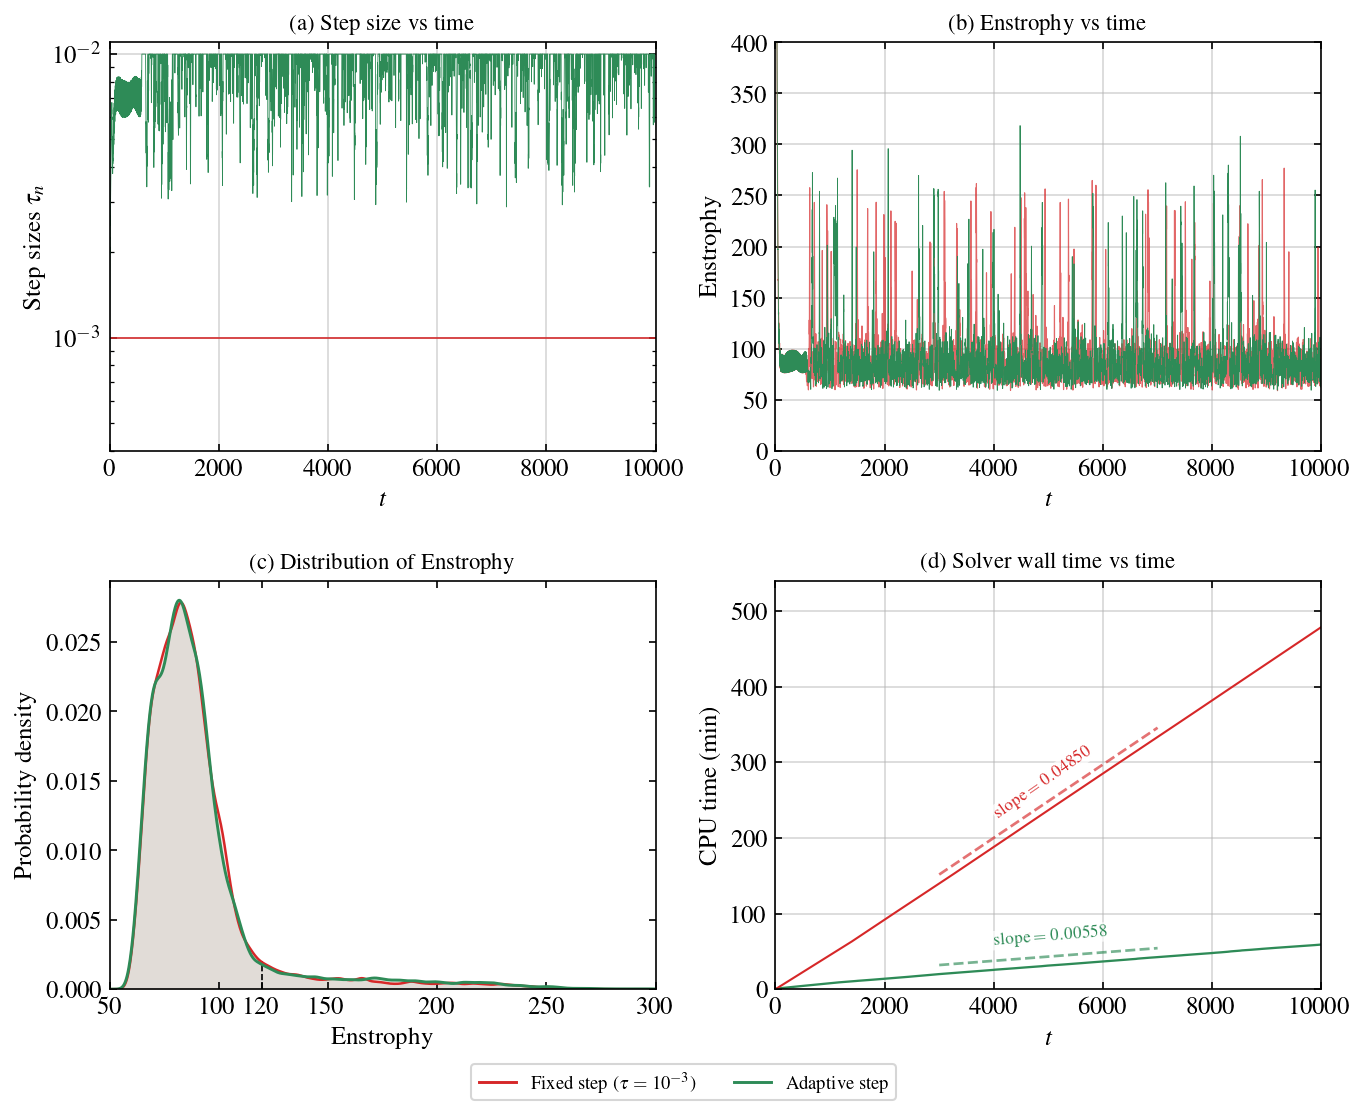

In [24]:
# ── Variable-step 自适应步长诊断：2×2 子图（只比较 1e-3 与 adaptive）──────
#
# (a) 步长 τ 随时间变化
# (b) Enstrophy 随时间变化
# (c) Enstrophy distribution comparison
# (d) 物理时间 t 与 CPU time 的关系

fixed_key = "tau=1e-3"
fixed_plot_specs_1e3 = {fixed_key: fixed_run_specs[fixed_key]}
fixed_spec_1e3 = fixed_plot_specs_1e3[fixed_key]
adaptive_color = adaptive_spec["color"]
adaptive_label = adaptive_spec["label"]

stride = 50
t = tn_vs[::stride]
t_tau = tn_vs[:len(tau_vs):stride]
tau = tau_vs[::stride]
E = Enstrophy_vs[::stride]

ensure_enstrophy_kdes(
    t0=kde_t_start if "kde_t_start" in globals() else 1000.0,
    t1=kde_t_end if "kde_t_end" in globals() else 10000.0,
    fixed_dt=kde_uniform_dt if "kde_uniform_dt" in globals() else 2.0e-2,
)

fig, axes = plt.subplots(2, 2, figsize=(9, 7), constrained_layout=True, dpi=150)
fig.set_constrained_layout_pads(h_pad=0.05, hspace=0.08)

# ── (a) 步长随时间变化 ──────────────────────────────────────────────────────
ax = axes[0, 0]
tau_fixed = fixed_spec_1e3["data"]["tau_value"]
ax.hlines(
    tau_fixed, 0, 10000,
    color=fixed_spec_1e3["color"], linewidth=0.9, alpha=0.85, linestyle="-",
    rasterized=True,
)
ax.plot(t_tau, tau, color=adaptive_color, linewidth=0.4, rasterized=True)
ax.set_yscale("log")
ax.set_xlim(0, 10000)
ax.set_ylim(4.0e-4, max(1.2e-3, 1.1 * np.nanmax(tau)))
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"Step sizes $\tau_n$")
ax.set_title(r"(a) Step size vs time", loc="center", fontsize=11)
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.grid(alpha=0.5)

# ── (b) Enstrophy 随时间变化 ────────────────────────────────────────────────
ax = axes[0, 1]
data_1e3 = fixed_spec_1e3["data"]
stride_fixed = max(1, len(data_1e3["tn"]) // 20000)
ax.plot(
    data_1e3["tn"][::stride_fixed],
    data_1e3["Enstrophy"][::stride_fixed],
    color=fixed_spec_1e3["color"], alpha=0.70, linewidth=0.55,
    rasterized=True,
)
ax.plot(t, E, color=adaptive_color, linewidth=0.4, rasterized=True)
ax.set_xlim(0, 10000)
ax.set_ylim(0, 400)
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"Enstrophy")
ax.set_title(r"(b) Enstrophy vs time", loc="center", fontsize=11)
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.grid(alpha=0.5)

# ── (c) Enstrophy distribution comparison ────────────────────────────────
ax = axes[1, 0]
ax.vlines(120, 0, 0.002, color="k", linestyles="--", linewidth=0.8)
pdf_1e3 = fixed_pdfs[fixed_key]
ax.fill_between(Z_grid, pdf_1e3, color=fixed_spec_1e3["color"], alpha=0.10, linewidth=0)
ax.plot(Z_grid, pdf_1e3, color=fixed_spec_1e3["color"], linewidth=1.2)
ax.fill_between(Z_grid, pdf_vs, color=adaptive_color, alpha=0.12, linewidth=0)
ax.plot(Z_grid, pdf_vs, color=adaptive_color, linewidth=1.4)
ax.set_xticks([50, 100, 120, 150, 200, 250, 300])
ax.set_xlim(50, 300)
ax.set_ylim(bottom=0)
ax.set_xlabel(r"Enstrophy")
ax.set_ylabel(r"Probability density")
ax.set_title(r"(c) Distribution of Enstrophy", fontsize=11)
ax.tick_params(which="both", direction="in", top=True, right=True)

# ── (d) 物理时间 t 与 CPU time 的关系 ──────────────────────────────────────
ax = axes[1, 1]

cpu_time_scale = 1.0
cpu_time_factors = {
    "adaptive": 1.0,
    "tau=1e-3": 1.0,
}
fit_t0, fit_t1 = 3000.0, 7000.0

def scaled_cpu_minutes(cpu_time, factor=1.0):
    return cpu_time / 60 * cpu_time_scale * factor

def downsample_for_plot(x, target_points=20000):
    return max(1, len(x) // target_points)

def fit_cpu_slope(time, cpu_minutes, t0=fit_t0, t1=fit_t1):
    mask = (time >= t0) & (time <= t1)
    if np.count_nonzero(mask) < 2:
        raise ValueError(f"Not enough points to fit CPU slope on [{t0}, {t1}].")
    return np.polyfit(time[mask], cpu_minutes[mask], 1)

s_vs = downsample_for_plot(tn_vs)
t_vs_plot = tn_vs[::s_vs]
cpu_vs_minutes = scaled_cpu_minutes(CPU_vs[::s_vs], factor=cpu_time_factors["adaptive"])
ax.plot(
    t_vs_plot, cpu_vs_minutes,
    color=adaptive_color, linewidth=1.1, rasterized=True, linestyle="-",
)

s_fix = downsample_for_plot(data_1e3["tn"])
t_fix_plot = data_1e3["tn"][::s_fix]

cpu_fix_minutes = scaled_cpu_minutes(
    data_1e3["CPU_time"][::s_fix],
    factor=cpu_time_factors[fixed_key],
)
ax.plot(
    t_fix_plot, cpu_fix_minutes,
    color=fixed_spec_1e3["color"], linewidth=1.0, linestyle="-", rasterized=True,
)

k_ada, b_ada = fit_cpu_slope(t_vs_plot, cpu_vs_minutes)
k_fix, b_fix = fit_cpu_slope(t_fix_plot, cpu_fix_minutes)
ymax_cpu = max(
    np.nanmax(scaled_cpu_minutes(CPU_vs, factor=cpu_time_factors["adaptive"])),
    np.nanmax(scaled_cpu_minutes(data_1e3["CPU_time"], factor=cpu_time_factors[fixed_key])),
)
fit_line_y_offset = 0.025 * ymax_cpu
t_line = np.array([fit_t0, fit_t1])
label_x = fit_t1 - 3000.0

ax.set_xlim(0, 10000)
ax.set_ylim(0, 1.10 * (ymax_cpu + fit_line_y_offset))

def data_line_angle(ax, slope, intercept, x0, x1, y_offset=0.0):
    p0 = ax.transData.transform((x0, slope * x0 + intercept + y_offset))
    p1 = ax.transData.transform((x1, slope * x1 + intercept + y_offset))
    dx, dy = p1 - p0
    return np.degrees(np.arctan2(dy, dx))

for color, slope, intercept, label_dx in [
    (adaptive_color, k_ada, b_ada, 0.0),
    (fixed_spec_1e3["color"], k_fix, b_fix, 120.0),
]:
    y_line = slope * t_line + intercept + fit_line_y_offset
    ax.plot(t_line, y_line, color=color, linewidth=1.3, linestyle="--", alpha=0.65)
    label_xi = label_x + label_dx
    label_y = slope * label_xi + intercept + fit_line_y_offset
    angle = data_line_angle(ax, slope, intercept, fit_t0, fit_t1, fit_line_y_offset)
    ax.annotate(
        rf"slope $={slope:.5f}$",
        xy=(label_xi, label_y), xytext=(0, 6), textcoords="offset points",
        color=color, fontsize=8.2, ha="left", va="bottom",
        rotation=angle, rotation_mode="anchor",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.70, pad=1.0),
    )

print(f"Recorded solver-time scale: ×{cpu_time_scale:g}")
print(f"CPU slope fitting window: [{fit_t0:g}, {fit_t1:g}]")
print(f"Adaptive slope : {k_ada:.4f} min/t  (intercept {b_ada:.3f})")
print(f"{fixed_key:<10} slope : {k_fix:.4f} min/t   speedup vs adaptive: {k_fix/k_ada:.2f}×")

ax.set_xlabel(r"$t$")
ax.set_ylabel(r"CPU time (min)")
ax.set_title(r"(d) Solver wall time vs time", loc="center", fontsize=11)
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.grid(alpha=0.5)

legend_handles = [
    plt.Line2D([0], [0], color=fixed_spec_1e3["color"], linewidth=1.4, label=fixed_spec_1e3["label"]),
    plt.Line2D([0], [0], color=adaptive_color, linewidth=1.4, label=adaptive_label),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=2, fontsize=9,
           frameon=True, bbox_to_anchor=(0.5, -0.05))

plt.savefig("fig/vs_diagnostics_1e3_adaptive.pdf", dpi=150, bbox_inches="tight")
plt.show()


(50.0, 400.0)

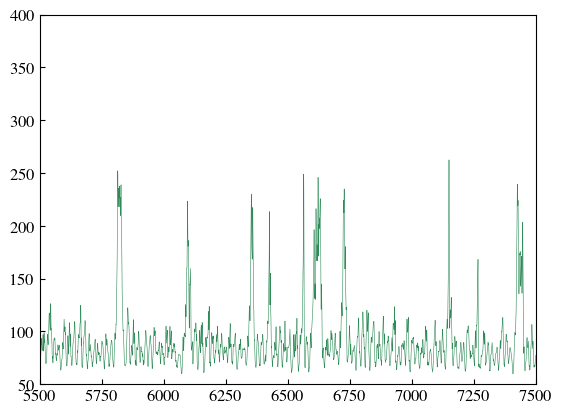

In [14]:
# plt.plot(
#     data_5e4["tn"][::stride_fixed], data_5e4["Enstrophy"][::stride_fixed],
#     color=fixed_spec_5e4["color"], alpha=0.70, linewidth=0.55, rasterized=True)

# plt.hlines(130, 0, 10000, color="k", linestyles="--", linewidth=0.8)
# # plt.hlines(150, 0, 10000, color="k", linestyles="--", linewidth=0.8)
plt.plot(t, E, color=adaptive_color, linewidth=0.4, rasterized=True)
plt.xlim(5500, 7500)
plt.ylim(50, 400)

In [15]:
# ── Bursting 事件统计：连续超过阈值且峰值超过 200 的一段时间算作一个 burst ─────
#
# 对两个固定步长和自适应步长分别统计 burst 事件。

t_cutoff_burst = 500
peak_threshold_burst = 200.0

def empty_burst_result(threshold, peak_threshold):
    empty = np.asarray([])
    return {
        "threshold": threshold,
        "peak_threshold": peak_threshold,
        "start_indices": empty.astype(int),
        "end_indices": empty.astype(int),
        "start_times": empty,
        "end_times": empty,
        "durations": empty,
        "time_intervals": empty,
        "clean_time_intervals": empty,
        "clean_interval_mask": np.asarray([], dtype=bool),
        "peak_values": empty,
        "count": 0,
        "clean_interval_count": 0,
        "max_duration": np.nan,
        "mean_duration": np.nan,
        "mean_interval": np.nan,
        "mean_clean_interval": np.nan,
    }

def detect_burst_segments(t, E, threshold, t_cutoff=0, peak_threshold=peak_threshold_burst):
    mask = t >= t_cutoff
    t_ss = t[mask]
    E_ss = E[mask]

    above = E_ss > threshold
    if not np.any(above):
        return empty_burst_result(threshold, peak_threshold)

    padded = np.r_[False, above, False]
    transitions = np.diff(padded.astype(np.int8))
    start_indices_all = np.flatnonzero(transitions == 1)
    end_indices_all = np.flatnonzero(transitions == -1) - 1
    peak_values_all = np.asarray([
        np.max(E_ss[i0:i1 + 1]) for i0, i1 in zip(start_indices_all, end_indices_all)
    ])

    keep = peak_values_all > peak_threshold
    if not np.any(keep):
        return empty_burst_result(threshold, peak_threshold)

    start_indices = start_indices_all[keep]
    end_indices = end_indices_all[keep]
    peak_values = peak_values_all[keep]

    start_times = t_ss[start_indices]
    end_times = t_ss[end_indices]
    durations = end_times - start_times
    time_intervals = np.diff(start_times)
    clean_interval_mask = np.asarray([
        not np.any(above[i_end + 1:i_next])
        for i_end, i_next in zip(end_indices[:-1], start_indices[1:])
    ], dtype=bool)
    clean_time_intervals = np.asarray([
        t_ss[i_next] - t_ss[i_end]
        for i_end, i_next in zip(end_indices[:-1], start_indices[1:])
    ])[clean_interval_mask]

    return {
        "threshold": threshold,
        "peak_threshold": peak_threshold,
        "start_indices": start_indices,
        "end_indices": end_indices,
        "start_times": start_times,
        "end_times": end_times,
        "durations": durations,
        "time_intervals": time_intervals,
        "clean_time_intervals": clean_time_intervals,
        "clean_interval_mask": clean_interval_mask,
        "peak_values": peak_values,
        "count": len(durations),
        "clean_interval_count": len(clean_time_intervals),
        "max_duration": np.max(durations),
        "mean_duration": np.mean(durations),
        "mean_interval": np.mean(time_intervals) if len(time_intervals) else np.nan,
        "mean_clean_interval": np.mean(clean_time_intervals) if len(clean_time_intervals) else np.nan,
    }

if "steady_moments_fixed" not in globals() or "steady_moments_vs" not in globals():
    def weighted_moments(x, w=None):
        mu1 = np.average(x, weights=w)
        mu2 = np.average(x**2, weights=w)
        var = np.average((x - mu1)**2, weights=w)
        std = np.sqrt(var)
        return mu1, mu2, var, std

    steady_moments_fixed = {}
    for key, spec in fixed_run_specs.items():
        data = spec["data"]
        i0 = int(np.searchsorted(data["tn"], 1000, side="left"))
        samples = data["Enstrophy"][i0:]
        mu1, mu2, var, std = weighted_moments(samples)
        steady_moments_fixed[key] = {
            "samples": samples,
            "mean": mu1,
            "second_moment": mu2,
            "variance": var,
            "std": std,
        }

    mask_vs_mom = tn_vs >= 1000
    E_vs_ss = Enstrophy_vs[mask_vs_mom]
    w_vs = trapezoidal_point_weights(tn_vs[mask_vs_mom])
    mu1_vs, mu2_vs, var_vs, std_vs = weighted_moments(E_vs_ss, w=w_vs)
    steady_moments_vs = {
        "samples": E_vs_ss,
        "weights": w_vs,
        "mean": mu1_vs,
        "second_moment": mu2_vs,
        "variance": var_vs,
        "std": std_vs,
    }

burst_fixed = {}
for key, spec in fixed_run_specs.items():
    threshold = steady_moments_fixed[key]["mean"] + 2 * steady_moments_fixed[key]["std"]
    burst_fixed[key] = detect_burst_segments(
        spec["data"]["tn"], spec["data"]["Enstrophy"],
        threshold=threshold, t_cutoff=t_cutoff_burst,
    )

burst_vs = detect_burst_segments(
    tn_vs, Enstrophy_vs,
    threshold=steady_moments_vs["mean"] + 2 * steady_moments_vs["std"],
    t_cutoff=t_cutoff_burst,
)

# Backward-compatible default fixed-step alias.
burst_fs = burst_fixed[default_fs_key]

k_values_burst = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
burst_count_rows = []
for k in k_values_burst:
    threshold_vs = steady_moments_vs["mean"] + k * steady_moments_vs["std"]
    burst_k_vs = detect_burst_segments(tn_vs, Enstrophy_vs, threshold_vs, t_cutoff_burst)
    for key, spec in fixed_run_specs.items():
        threshold_fixed = steady_moments_fixed[key]["mean"] + k * steady_moments_fixed[key]["std"]
        burst_k_fixed = detect_burst_segments(
            spec["data"]["tn"], spec["data"]["Enstrophy"],
            threshold_fixed, t_cutoff_burst,
        )
        fixed_count = burst_k_fixed["count"]
        adaptive_count = burst_k_vs["count"]
        count_error_pct = 100 * abs(fixed_count - adaptive_count) / fixed_count if fixed_count > 0 else np.nan
        burst_count_rows.append({
            "k": k,
            "fixed run": key,
            "fixed threshold": threshold_fixed,
            "fixed burst count": fixed_count,
            "adaptive threshold": threshold_vs,
            "adaptive burst count": adaptive_count,
            "count error (%)": count_error_pct,
        })

try:
    import pandas as pd
    burst_count_table = pd.DataFrame(burst_count_rows)
    display(burst_count_table.style.format({
        "k": "{:.1f}",
        "fixed threshold": "{:.4f}",
        "adaptive threshold": "{:.4f}",
        "count error (%)": "{:.2f}",
    }))
except ImportError:
    burst_count_table = burst_count_rows
    print(f"{'k':>4} {'fixed run':>10} {'fixed thr.':>14} {'fixed':>8} {'adapt thr.':>14} {'adapt':>8} {'err (%)':>9}")
    print("-" * 86)
    for row in burst_count_rows:
        print(
            f"{row['k']:>4.1f} {row['fixed run']:>10} {row['fixed threshold']:>14.4f} "
            f"{row['fixed burst count']:>8d} {row['adaptive threshold']:>14.4f} "
            f"{row['adaptive burst count']:>8d} {row['count error (%)']:>9.2f}"
        )

def print_burst_duration_summary(label, burst):
    if burst["count"] == 0:
        print(
            f"{label} threshold = {burst['threshold']:.4f}, "
            f"peak > {burst['peak_threshold']:.1f}, count = 0"
        )
        return

    i_max = int(np.argmax(burst["durations"]))
    print(
        f"{label} threshold = {burst['threshold']:.4f}, "
        f"peak > {burst['peak_threshold']:.1f}, count = {burst['count']}"
    )
    print(f"  max duration  = {burst['max_duration']:.4f} "
          f"on [{burst['start_times'][i_max]:.4f}, {burst['end_times'][i_max]:.4f}], "
          f"peak = {burst['peak_values'][i_max]:.4f}")
    print(f"  mean duration = {burst['mean_duration']:.4f}")
    print(f"  mean interval = {burst['mean_interval']:.4f}")
    print(
        f"  clean intervals = {burst['clean_interval_count']}/{max(burst['count'] - 1, 0)}, "
        f"mean clean interval = {burst['mean_clean_interval']:.4f}"
    )

for key, spec in fixed_run_specs.items():
    print_burst_duration_summary(spec["label"], burst_fixed[key])
print_burst_duration_summary(adaptive_spec["label"], burst_vs)


,k,fixed run,fixed threshold,fixed burst count,adaptive threshold,adaptive burst count,count error (%)
0,1.0,tau=1e-3,116.6413,41,119.3953,35,14.63
1,1.0,tau=5e-4,121.5987,45,119.3953,35,22.22
2,2.0,tau=1e-3,143.2073,43,148.0532,40,6.98
3,2.0,tau=5e-4,151.1737,49,148.0532,40,18.37
4,3.0,tau=1e-3,169.7732,47,176.7110,49,4.26
5,3.0,tau=5e-4,180.7487,60,176.7110,49,18.33
6,4.0,tau=1e-3,196.3392,48,205.3689,50,4.17
7,4.0,tau=5e-4,210.3237,56,205.3689,50,10.71
8,5.0,tau=1e-3,222.9051,39,234.0267,35,10.26
9,5.0,tau=5e-4,239.8987,29,234.0267,35,20.69


Fixed step ($\tau=10^{-3}$) threshold = 143.2073, peak > 200.0, count = 43
  max duration  = 18.9610 on [6820.5200, 6839.4810], peak = 255.9691
  mean duration = 8.8999
  mean interval = 206.9852
  clean intervals = 23/42, mean clean interval = 113.4523
Fixed step ($\tau=5\times10^{-4}$) threshold = 151.1737, peak > 200.0, count = 49
  max duration  = 32.3255 on [7780.6085, 7812.9340], peak = 287.4967
  mean duration = 9.0024
  mean interval = 193.0711
  clean intervals = 26/48, mean clean interval = 107.0484
Adaptive step threshold = 148.0532, peak > 200.0, count = 40
  max duration  = 34.4384 on [8280.9697, 8315.4081], peak = 279.9037
  mean duration = 10.2922
  mean interval = 236.2400
  clean intervals = 22/39, mean clean interval = 175.2946


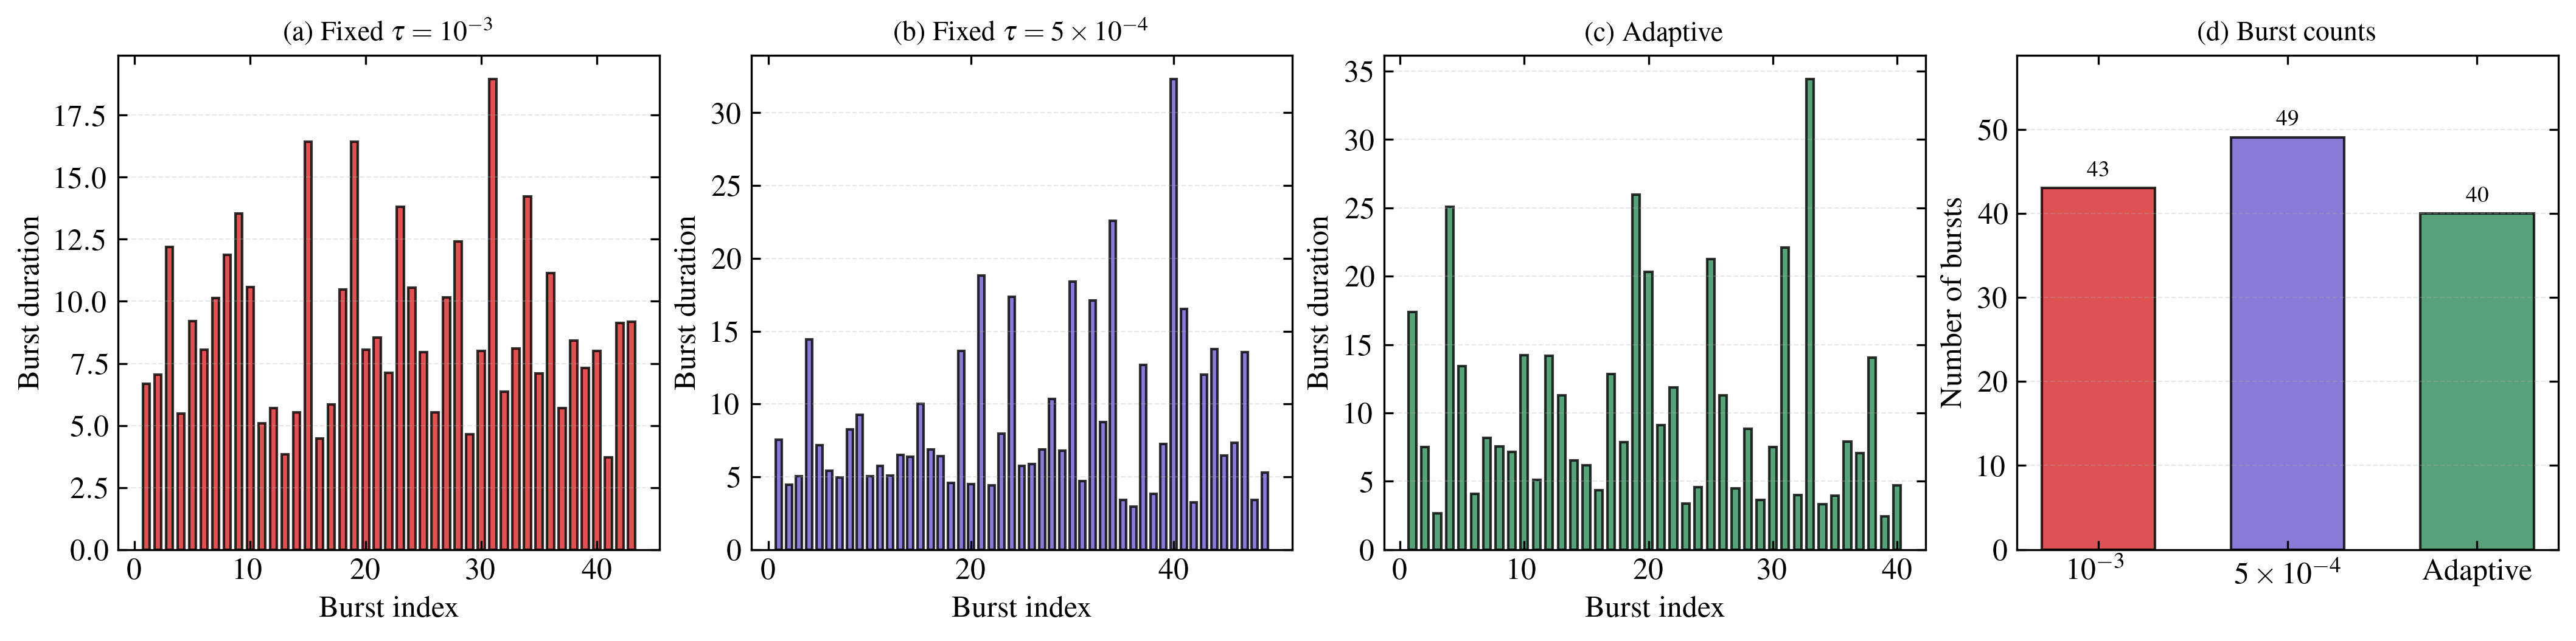

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.4), constrained_layout=True, dpi=300)

# ── (a)-(c) Burst duration bar plots ──────────────────────────────────────
duration_panels = [
    ("tau=1e-3", fixed_run_specs["tau=1e-3"], burst_fixed["tau=1e-3"], r"(a) Fixed $\tau=10^{-3}$"),
    ("tau=5e-4", fixed_run_specs["tau=5e-4"], burst_fixed["tau=5e-4"], r"(b) Fixed $\tau=5\times10^{-4}$"),
    ("adaptive", adaptive_spec, burst_vs, r"(c) Adaptive"),
]

for ax, (_, spec, burst, title) in zip(axes[:3], duration_panels):
    durations = burst["durations"]
    x_pos = np.arange(1, len(durations) + 1)
    ax.bar(x_pos, durations, color=spec["color"],
           edgecolor="black", alpha=0.8, width=0.6)
    ax.set_xlabel(r"Burst index")
    ax.set_ylabel(r"Burst duration")
    ax.set_title(title, fontsize=11)
    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.grid(axis="y", alpha=0.3, linestyle="dashed", linewidth=0.5)

# ── (d) Burst count comparison ───────────────────────────────────────────
ax = axes[3]
labels = [r"$10^{-3}$", r"$5\times10^{-4}$", r"Adaptive"]
counts = [burst_fixed["tau=1e-3"]["count"], burst_fixed["tau=5e-4"]["count"], burst_vs["count"]]
colors = [fixed_run_specs["tau=1e-3"]["color"], fixed_run_specs["tau=5e-4"]["color"], adaptive_spec["color"]]
x = np.arange(len(labels))
bars = ax.bar(x, counts, color=colors, edgecolor="black", alpha=0.8, width=0.6)
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_ylim(0, max(counts) * 1.20 if counts else 1)
ax.set_xticks(x, labels)
ax.set_ylabel(r"Number of bursts")
ax.set_title(r"(d) Burst counts", fontsize=11)
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.grid(axis="y", alpha=0.3, linestyle="dashed", linewidth=0.5)

from pathlib import Path
Path("fig").mkdir(exist_ok=True)
plt.savefig("fig/bursting_event_comparison.pdf", dpi=300, bbox_inches="tight", pad_inches=0.2)
plt.show()

In [ ]:
\subsection{Long-time efficiency and statistics}
The next example examines the efficiency and statistical fidelity of the adaptive strategy over a genuinely long time interval. In this regime, pointwise agreement between individual trajectories is not expected because of the sensitive dependence of the bursting dynamics on temporal perturbations. We therefore compare boundedness, representative flow scales, enstrophy distributions, and intermittent-event statistics.

\begin{exm}[Kolmogorov forcing: case 3, long-time]
We consider the Kolmogorov flow on $\Omega=(0,2\pi)^2$ with $m=4$, $\nu=1/40$, $\gamma=1000$, and the perturbed initial streamfunction $\psi_0=\psi_\varepsilon$ with $\varepsilon=4$. The spatial discretization uses a $128\times128$ Fourier pseudospectral grid. Before the long-time computation, the initial vorticity is evolved by ETDRK4 up to $t=1$ with $\tau=2.5\times10^{-3}$. Both long-time solutions are then computed by the SDIRK2-mr-SAV scheme up to $T=10000$. The fixed-step computation uses $\tau=10^{-3}$, whereas the adaptive computation uses $\tau_{\min}=10^{-5}$, $\tau_{\max}=10^{-2}$, $\mathrm{rtol}=5\times10^{-5}$, and $\mathrm{rtol}_q=10^{-2}$; its accepted step sizes lie between $5\times10^{-4}$ and $10^{-2}$.

The interval $1000\leq t\leq10000$ is used for time-averaged flow scales and enstrophy moments. Trapezoidal time weights are used for the adaptive trajectory on its nonuniform temporal grid. To compare probability distributions without sampling-density bias, all trajectories are resampled on the common grid $t_j=1000+0.02j$, $j=0,\ldots,400000$, over $1000\leq t\leq9000$. The adaptive data are evaluated by shape-preserving piecewise cubic Hermite interpolation, and equal-weight Gaussian kernel density estimates are then constructed from the resampled values.
\end{exm}

Figure~\ref{fig:adaptive_step_k} summarizes the long-time diagnostics. Panel~(a) shows that the controller reduces the step size during dynamically active episodes and increases it during relatively quiescent intervals. On $t\geq1000$, the Pearson correlation coefficient between $\tau_n$ and the magnitude of the enstrophy rate is $-0.6056$, confirming that rapid temporal variation is associated with smaller time steps. Panel~(b) shows that the fixed-step and adaptive trajectories separate over long time, as expected in this sensitive regime, while their enstrophy remains bounded. Panel~(c) demonstrates close agreement between the corresponding long-time enstrophy distributions. Panel~(d) reports the cumulative solver wall-clock time recorded by \texttt{time.perf\_counter}. The adaptive computation requires $1{,}179{,}984$ accepted steps and $59.00$ minutes, whereas the fixed-step computation requires $10{,}000{,}000$ steps and $478.69$ minutes. Thus, the ratio of the recorded cumulative times is $8.11$; a linear fit over $3000\leq t\leq7000$ gives a comparable speedup factor of $8.69$. These timings include the time-stepping kernels and rejected adaptive trials but exclude initialization, diagnostic evaluation, snapshot storage, and file output.

\begin{figure}[htbp]
    \centering
    \includegraphics[width=0.9\linewidth]{figure/vs_diagnostics_1e3_adaptive.pdf}
    \caption{Long-time diagnostics for the Kolmogorov flow with $\nu=1/40$ and $m=4$. (a) Adaptive step sizes $\tau_n$, with the fixed step $\tau=10^{-3}$ shown for reference. (b) Enstrophy histories of the fixed-step and adaptive computations. (c) Equal-weight kernel density estimates of enstrophy obtained on the common uniform time grid over $1000\leq t\leq9000$. (d) Recorded cumulative solver wall-clock time in minutes.}
    \label{fig:adaptive_step_k}
\end{figure}

The representative velocity is defined by
\[
U=\left(\frac{2}{L^2(t_1-t_0)}\int_{t_0}^{t_1}E(t)\,\mathrm{d}t\right)^{1/2},
\qquad Re_U=\frac{UL}{\nu},
\qquad T_e=\frac{L}{U},
\]
where $L=2\pi$, $t_0=1000$, and $t_1=10000$. Table~\ref{tab:moment_flow_scales_comparison} shows that the adaptive computation reproduces the mean enstrophy and the representative flow scales accurately. The fluctuation-sensitive quantities exhibit larger differences: the variance and standard deviation differ from the fixed-step values by $16.37\%$ and $7.87\%$, respectively. This is consistent with the greater sensitivity of intermittent fluctuations than of long-time means.

\begin{table}[htbp]
\centering
\scriptsize
\caption{Long-time enstrophy statistics and time-averaged flow scales obtained by the fixed-step SDIRK2-mr-SAV computation with $\tau=10^{-3}$ and its adaptive counterpart. The averaging interval is $1000\leq t\leq10000$, and the relative difference is measured with respect to the fixed-step result.}
\label{tab:moment_flow_scales_comparison}
\begin{tabular}{@{}lccc@{}}
\toprule
Quantity & Fixed $\tau=10^{-3}$ & Adaptive step & Relative difference \\
\midrule
\multicolumn{4}{@{}l}{\textit{Long-time statistics of the enstrophy}} \\
Mean $\mathbb{E}[\mathcal{E}]$ & $90.0754$ & $90.7375$ & $0.735\%$ \\
Second moment $\mathbb{E}[\mathcal{E}^2]$ & $8819.3277$ & $9054.5648$ & $2.667\%$ \\
Variance $\operatorname{Var}(\mathcal{E})$ & $705.7493$ & $821.2723$ & $16.369\%$ \\
Standard deviation $\operatorname{Std}(\mathcal{E})$ & $26.5659$ & $28.6578$ & $7.874\%$ \\
\midrule
\multicolumn{4}{@{}l}{\textit{Time-averaged flow scales}} \\
Typical velocity $U$ & $1.1718$ & $1.1704$ & $-0.115\%$ \\
Representative Reynolds number $Re_U$ & $294.5024$ & $294.1640$ & $-0.115\%$ \\
Eddy-turnover time $T_e$ & $5.3621$ & $5.3682$ & $0.115\%$ \\
\bottomrule
\end{tabular}
\end{table}

Table~\ref{tab:tv_comparison} quantifies the distributional discrepancy. On an interval $I$, the total variation distance is computed as $\frac12\int_I|p_{\mathrm{fix}}-p_{\mathrm{ada}}|\,\mathrm{d}\mathcal{E}$, while the relative $L^1$ error is normalized by the mean probability mass of the two distributions on $I$. The full-range total variation distance is $0.0219$. The larger relative error in the interval $120\leq\mathcal{E}\leq400$ reflects the lower probability mass and greater sampling sensitivity of the bursting tail.

\begin{table}[htbp]
\centering
\scriptsize
\caption{Discrepancy between the enstrophy distributions obtained by the fixed-step SDIRK2-mr-SAV computation with $\tau=10^{-3}$ and its adaptive counterpart. Both kernel density estimates use equal-weight samples on the common uniform time grid over $1000\leq t\leq9000$.}
\label{tab:tv_comparison}
\begin{tabular}{@{}lcc@{}}
\toprule
Enstrophy range & Total variation distance & Relative $L^1$ error \\
\midrule
$0\leq\mathcal{E}\leq120$ & $0.014770$ & $3.220\%$ \\
$120\leq\mathcal{E}\leq400$ & $0.007095$ & $17.165\%$ \\
$0\leq\mathcal{E}\leq500$ & $0.021865$ & $4.373\%$ \\
\bottomrule
\end{tabular}
\end{table}

To assess intermittent events, the mean and standard deviation in Table~\ref{tab:moment_flow_scales_comparison} are first computed on $1000\leq t\leq10000$. For each computation and each $k$, a tail event is then defined as a connected component of $\mathcal{E}(t)>\mathbb{E}[\mathcal{E}]+k\operatorname{Std}(\mathcal{E})$ on $t\geq500$ whose peak exceeds $200$. The thresholds are therefore run dependent. Table~\ref{tab:burst_count_thresholds} reports the resulting counts. Their maximum relative difference is $14.63\%$, indicating reasonable qualitative agreement while also confirming that rare-event counts are more sensitive than low-order moments. For $k=2$, the fixed-step and adaptive computations identify $43$ and $40$ events, with mean durations $8.90$ and $10.29$, respectively. These durations correspond to approximately $1.7$--$1.9$ eddy-turnover times, whereas the mean intervals between event starts are approximately $39$--$44$ eddy-turnover times. Consequently, integrations spanning only a few turnover times can easily miss dynamically important bursts.

\begin{table}[htbp]
\centering
\scriptsize
\caption{Tail-event thresholds and counts for the fixed-step SDIRK2-mr-SAV computation with $\tau=10^{-3}$ and its adaptive counterpart. Events are searched on $t\geq500$ and are retained only when their peak enstrophy exceeds $200$.}
\label{tab:burst_count_thresholds}
\begin{tabular}{@{}cccccc@{}}
\toprule
$k$ & Fixed threshold & Adaptive threshold & Fixed count & Adaptive count & Relative difference \\
\midrule
$1$ & $116.6413$ & $119.3953$ & $41$ & $35$ & $14.63\%$ \\
$2$ & $143.2073$ & $148.0532$ & $43$ & $40$ & $6.98\%$ \\
$3$ & $169.7732$ & $176.7110$ & $47$ & $49$ & $4.26\%$ \\
$4$ & $196.3392$ & $205.3689$ & $48$ & $50$ & $4.17\%$ \\
$5$ & $222.9051$ & $234.0267$ & $39$ & $35$ & $10.26\%$ \\
\bottomrule
\end{tabular}
\end{table}

These tests do not establish convergence of invariant measures. They instead show that, for the present bursting-flow computation, adaptive SDIRK2-mr-SAV preserves bounded long-time dynamics and reproduces the principal fixed-step statistical diagnostics at substantially lower recorded solver cost.
